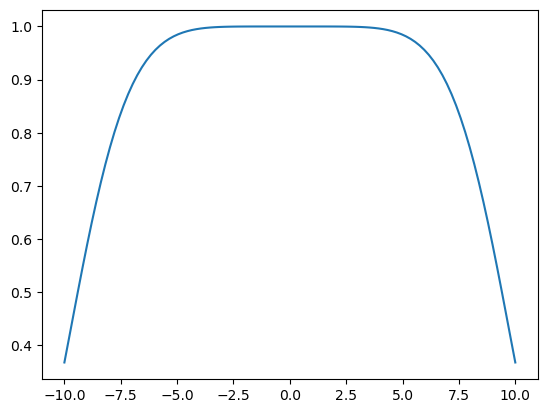

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# gaussian parameters
n = 6  # order of the Gaussian
A = 1  # amplitude

x = np.linspace(-10, 10, 100)
y = A * np.exp(-((x - 0)/10)**n)




plt.plot(x, y, label=f'Gaussian (n={n})')
# plt.yscale('log')

In [55]:
np.finfo(float).eps


2.220446049250313e-16

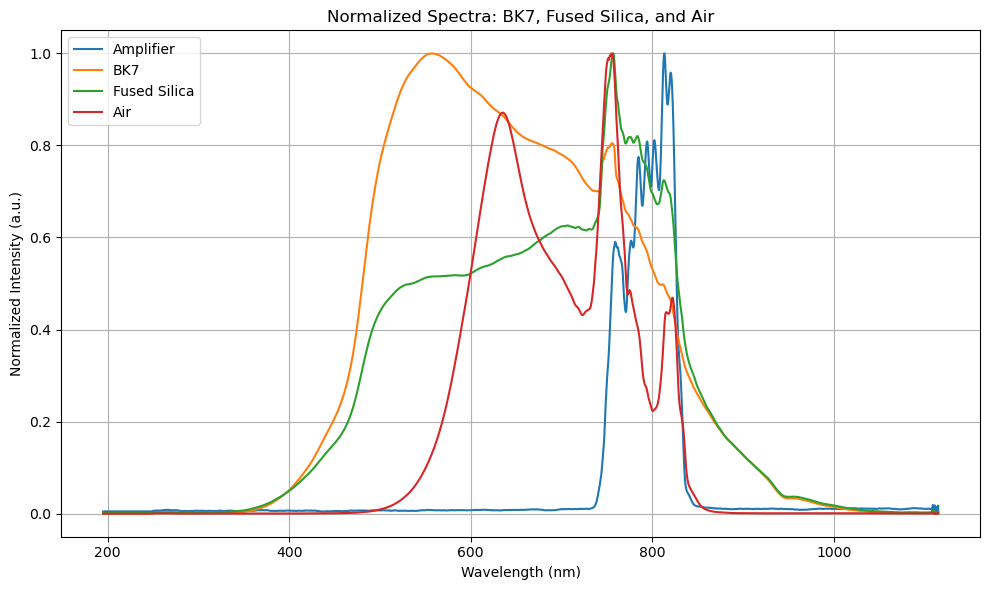

In [56]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.fft import ifft, fftshift, fftfreq
# from scipy.interpolate import interp1d
# from sklearn.preprocessing import MinMaxScaler



# def plot_from_csv(file_path, title):
#     df = pd.read_csv(file_path)
#     df.columns = ['Wavelength(nm)', 'Intensity']
    
#     # Normalize intensity between 0 and 1
#     x_nm = df['Wavelength(nm)'].values
#     y = df['Intensity'].values
#     y = MinMaxScaler().fit_transform(y.reshape(-1, 1)).flatten()
    
#     plt.plot(x_nm, y)
#     plt.title(f"Spectrum : {title}")
#     plt.xlabel("Wavelength (nm)")
#     plt.ylabel("Normalized Intensity")
#     plt.grid()
#     plt.show()


# plot_from_csv("mean_bk7_spectrum.csv", "BK7")
# plot_from_csv("mean_fs_spectrum.csv", "Fused Silica")
# plot_from_csv("mean_air_spectrum.csv", "Air")


from cProfile import label
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def load_and_normalize_csv(file_path):
    df = pd.read_csv(file_path)
    df.columns = ['Wavelength(nm)', 'Intensity']
    
    x_nm = df['Wavelength(nm)'].values
    y = df['Intensity'].values
    y = MinMaxScaler().fit_transform(y.reshape(-1, 1)).flatten()
    
    return x_nm, y

# Load and normalize each dataset
x_bk7, y_bk7 = load_and_normalize_csv("mean_bk7_spectrum.csv")
x_fs, y_fs = load_and_normalize_csv("mean_fs_spectrum.csv")
x_air, y_air = load_and_normalize_csv("mean_air_spectrum.csv")
x_amp, y_amp = load_and_normalize_csv("amplifier_spectrum.csv")

# Plot all on the same figure
plt.figure(figsize=(10,6))

plt.plot(x_amp, y_amp, label="Amplifier")
plt.plot(x_bk7, y_bk7, label="BK7")
plt.plot(x_fs, y_fs, label="Fused Silica")
plt.plot(x_air, y_air, label="Air")


plt.title("Normalized Spectra: BK7, Fused Silica, and Air")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity (a.u.)")
plt.grid()
plt.legend(loc = "upper left")
plt.tight_layout()


plt.savefig(f"Normalised Spectra", dpi=300, bbox_inches='tight')
plt.show()


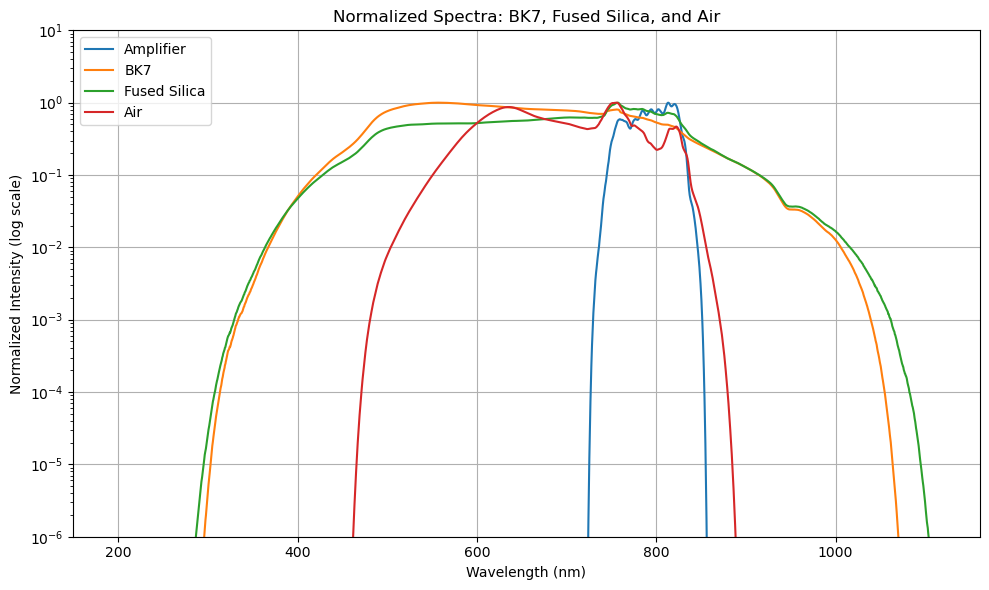

In [57]:
FILES = [
    {'fileloc': 'amplifier_spectrum.csv', 'center': 790, 'width': 120, 'order': 8, "name" : "Amplifier" },
    {'fileloc': 'mean_air_spectrum.csv', 'center': 675, 'width': 400, 'order': 10,  "name" : "Air"},
    {'fileloc': 'mean_bk7_spectrum.csv', 'center': 682.5,  'width': 725, 'order': 10,  "name" : "BK7"},
    {'fileloc': 'mean_fs_spectrum.csv', 'center': 695,  'width': 750, 'order': 8,  "name" : "Fused Silica"},
]


y_amp = taper_with_supergaussian(x_amp, y_amp, center=790, width=120, order=8)
y_air = taper_with_supergaussian(x_air, y_air, center=675, width=400, order=10)
y_bk7 = taper_with_supergaussian(x_bk7, y_bk7, center=682.5, width=725, order=10)
y_fs = taper_with_supergaussian(x_fs, y_fs, center=695, width=750, order=8)




def supergaussian(x, center, width, order, amplitude=1):
    return amplitude * np.exp(-((x - center) / (width / 2)) ** (2 * order))

def taper_with_supergaussian(x, y, center, width, order, amplitude=1):
    return y * supergaussian(x, center, width, order, amplitude)


# Plot all on the same figure
y_amp = taper_with_supergaussian(x_amp, y_amp, center=790, width=120, order=8)
y_air = taper_with_supergaussian(x_air, y_air, center=675, width=400, order=10)
y_bk7 = taper_with_supergaussian(x_bk7, y_bk7, center=682.5, width=725, order=10)
y_fs = taper_with_supergaussian(x_fs, y_fs, center=695, width=750, order=8)

plt.figure(figsize=(10, 6))
plt.plot(x_amp, y_amp, label="Amplifier")
plt.plot(x_bk7, y_bk7, label="BK7")
plt.plot(x_fs, y_fs, label="Fused Silica")
plt.plot(x_air, y_air, label="Air")


plt.title("Normalized Spectra: BK7, Fused Silica, and Air")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity (log scale)")
plt.grid()
plt.yscale("log")
plt.ylim(1e-6, 10)
plt.legend(loc="upper left")
plt.tight_layout()



plt.savefig(f"Normalised Spectra - log scale.png", dpi=300, bbox_inches='tight')  # Save before show
plt.show()


In [58]:
import csv

from nbformat import convert

def convert_txt_to_csv(txt_file_path, csv_file_path, delimiter=None):
    """
    Converts a TXT file with two columns into a CSV file with headers 'Wavelength' and 'Intensity'.
    
    :param txt_file_path: Path to the input TXT file
    :param csv_file_path: Path to the output CSV file
    :param delimiter: Delimiter used in the TXT file (default is any whitespace)
    """
    with open(txt_file_path, 'r') as txt_file:
        lines = txt_file.readlines()

    data = []
    for line in lines:
        if line.strip():  # skip empty lines
            parts = line.strip().split(delimiter)
            if len(parts) >= 2:
                wavelength, intensity = parts[0], parts[1]
                data.append([wavelength, intensity])

    with open(csv_file_path, 'w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['Wavelength(nm)', 'Intensity'])  # header
        writer.writerows(data)

    print(f"Conversion completed. CSV saved at: {csv_file_path}")
    
convert_txt_to_csv("amplifier_spectrum.txt", "amplifier_spectrum.csv")


Conversion completed. CSV saved at: amplifier_spectrum.csv
